In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185,

<h1>CUP - KNN</h1>
<p>Exploring the cup dataset with KNN Classifier.</p>
<hr/>

In [21]:
import importlib

import numpy as np
from sympy import false

import cross_common as cr
import cup_common as cc
import knn_common as kc
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from cross_common import MEE,MSE,RMSE,MAE,R2


In [3]:
importlib.reload(cc)
importlib.reload(kc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [4]:
# The common fold strategy used trough all models
outer_cv = cr.common_fold_strategy(False)
default_krange = list(range(1, 41, 2)) # <-- it means [1, 3, 5,..., 41]
default_metric = cr.MEE
common_scoring = cr.common_scoring(default_metric)
scaler = RobustScaler()

default_pipe = Pipeline([
    ("scaler", scaler),
    ("model", KNeighborsRegressor())
])

default_param_grid = {
    "model__n_neighbors": default_krange,
    "model__weights": ["uniform"],
    "model__p": [1, 2],          # 1=Manhattan, 2=Euclidean
    "model__metric": ["minkowski"]
}


<h3>Data Loading</h3>

In [5]:
df_train, df_test = cc.load_set()

# The train set used for model selection
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

y_tr = np.delete(y_tr,[0,1],axis=1)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [6]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 30.113958740234374
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-30.50204659 -29.0813179  -30.13298988 -30.00396729 -30.84947205]


<h3>Best Model</h3>

In [7]:
importlib.reload(cr)

gs = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=common_scoring,
    cv=outer_cv,
    n_jobs=-1,
    return_train_score=True
)

gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_base_model, best_base_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 40  splits: 5
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform'}
Best score: -10.062023162841797
Best model: Pipeline(steps=[('scaler', RobustScaler()),
                ('model', KNeighborsRegressor(n_neighbors=3))])


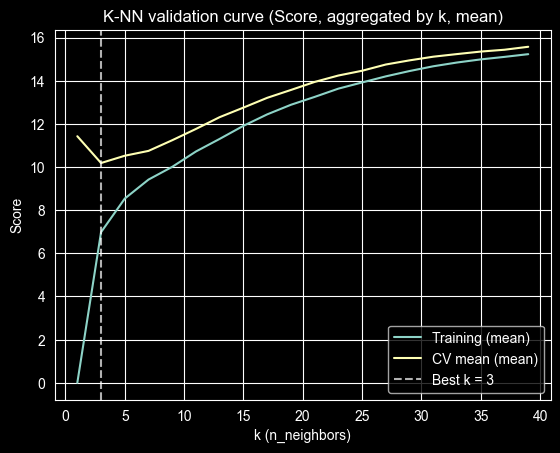

In [8]:
importlib.reload(kc)
kc.plot_knn_validation_curve_from_gs(gs,"mean")

<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>
<p>With distance-weighted KNN, the training error might be zero by construction, as each training point dominates its own prediction. Therefore, only the validation curve provides meaningful information about generalization.</p>

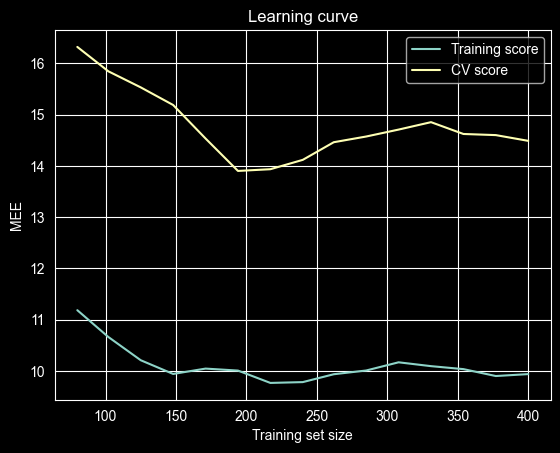

In [9]:
importlib.reload(cr)
cr.plot_learning_curve(best_base_model, X_tr, y_tr, outer_cv, scoring=common_scoring)

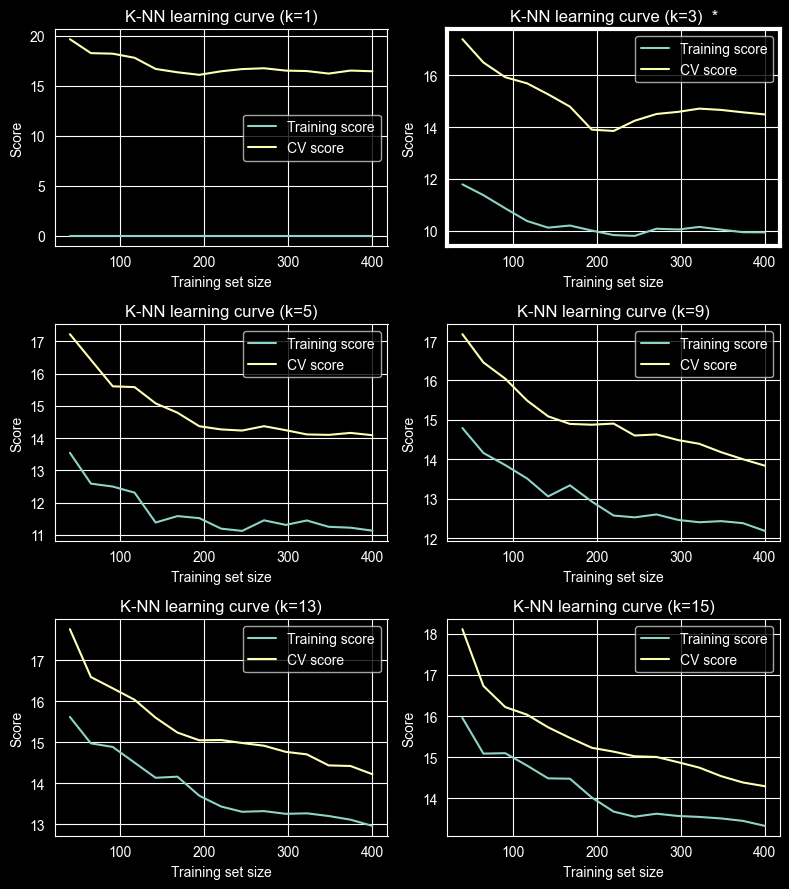

In [10]:
importlib.reload(kc)
kc.plot_knn_learning_curves_grid(
    best_base_model,
    X=X_tr,
    y=y_tr,
    cv=outer_cv,
    scoring=common_scoring
)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [11]:
from sklearn import clone
runner = cr.SklearnRegressorRunner(clone(gs.best_estimator_).set_params(**gs.best_params_))
non_nested_result = cr.kfold(runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 81.3491
Validation RMSE | 9.0194
Validation MEE  | 9.3783
Validation MAE  | 6.5651
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 100.4155
Validation RMSE | 10.0208
Validation MEE  | 10.5632
Validation MAE  | 7.4091
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 85.4777
Validation RMSE | 9.2454
Validation MEE  | 9.9489
Validation MAE  | 6.9599
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 4, train size: 400, val size: 100
 
Fold summary
-

In [12]:
#cr.kfold_regression_table(non_nested_result, use="mae", derive_rmse=True)

<p>Comparing the metrics obtained from grid search with the one originating from kfold function. They must match almost exaclty apart from sign which depends on the scoring function.</p>

In [13]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -10.0620 ± 0.4314
Best CV func score: 10.0620 ± 0.4314


<h3>Nested Cross Validation</h3>

In [14]:
importlib.reload(cr)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    default_pipe,
    param_grid=default_param_grid,
    scoring=common_scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 40  splits: 3
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform'}
Best score: -11.18945280710856
Best model: Pipeline(steps=[('scaler', RobustScaler()),
                ('model', KNeighborsRegressor(n_neighbors=3))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MSE  | 81.3491
Validation RMSE | 9.0194
Validation MEE  | 9.3783
Validation MAE  | 6.5651
Train           | samples: 400
Validation      | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 40  splits: 3
Best params: {'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}
Best score: -10.722045262654623
Best model: Pipeline(steps=[('scaler', RobustScale

<h3>Results</h3>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

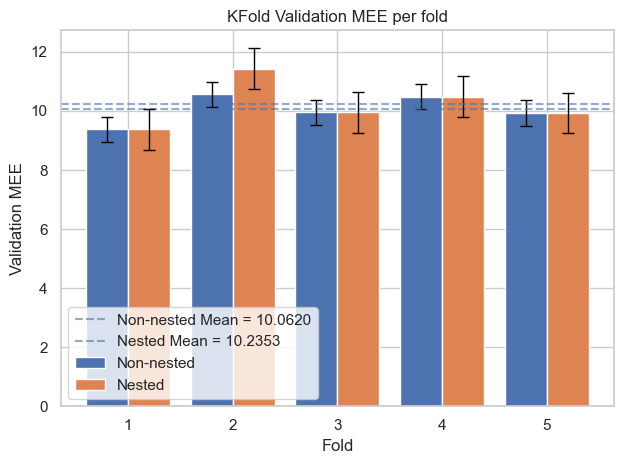

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,6.987435,9.378339,2.390903,34.22%
2,7.083441,11.429632,4.346191,61.36%
3,6.733813,9.948941,3.215128,47.75%
4,6.803669,10.488667,3.684997,54.16%
5,6.888616,9.930990,3.042375,44.17%
MEAN,6.899395,10.235314,3.335919,48.33%
STD,0.139929,0.774534,0.730808,10.25%


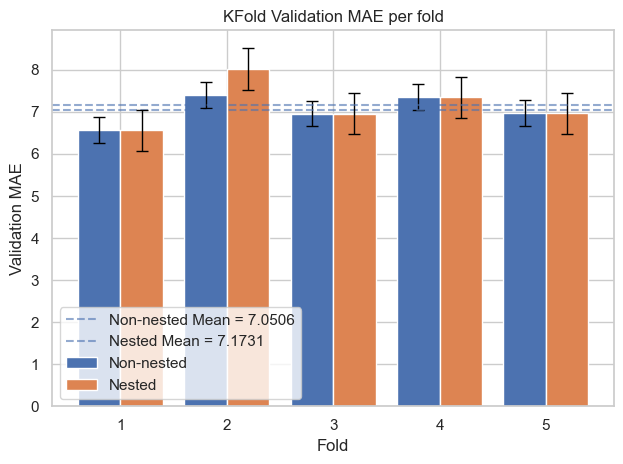

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,4.895366,6.565148,1.669783,34.11%
2,4.967673,8.021835,3.054162,61.48%
3,4.713687,6.959919,2.246233,47.65%
4,4.766439,7.349648,2.583210,54.20%
5,4.826414,6.969107,2.142693,44.40%
MEAN,4.833916,7.173132,2.339216,48.37%
STD,0.100910,0.549587,0.516258,10.31%


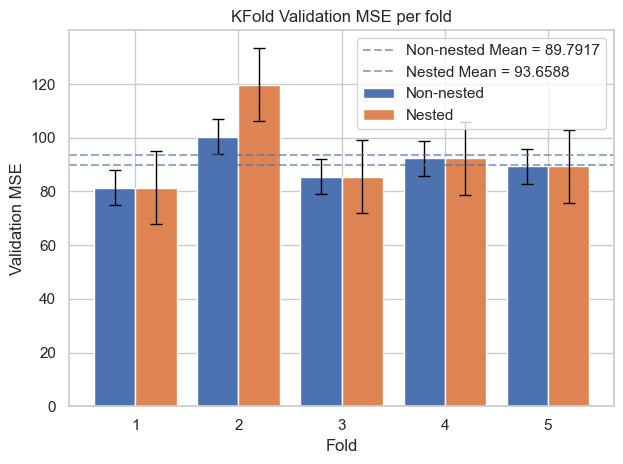

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,47.215740,81.349136,34.133396,72.29%
2,50.913322,119.750847,68.837524,135.21%
3,44.892082,85.477661,40.585579,90.41%
4,46.805153,92.346466,45.541313,97.30%
5,46.971043,89.369965,42.398922,90.27%
MEAN,47.359468,93.658815,46.299347,97.10%
STD,2.190700,15.160558,13.270408,23.23%


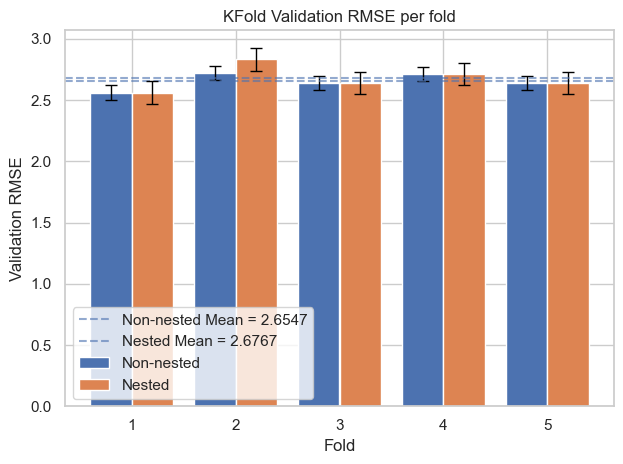

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,2.212547,2.562255,0.349707,15.81%
2,2.228828,2.832284,0.603457,27.08%
3,2.171103,2.638166,0.467063,21.51%
4,2.183218,2.711024,0.527806,24.18%
5,2.196910,2.639907,0.442996,20.16%
MEAN,2.198521,2.676727,0.478206,21.75%
STD,0.022934,0.101638,0.094900,4.25%


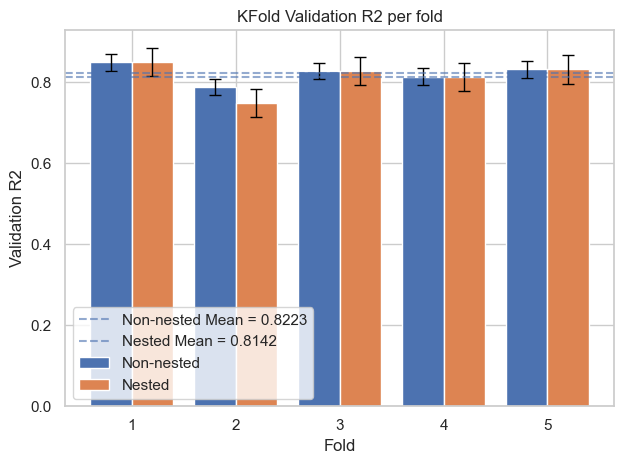

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,0.907986,0.849356,-0.058630,6.46%
2,0.902991,0.748349,-0.154642,17.13%
3,0.913492,0.827398,-0.086094,9.42%
4,0.910196,0.814273,-0.095923,10.54%
5,0.908839,0.831823,-0.077016,8.47%
MEAN,0.908701,0.814240,-0.094461,10.40%
STD,0.003819,0.038914,0.036339,4.05%


In [22]:
for metric in [MEE,MAE,MSE,RMSE,R2]:
    cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], metric)
    display(cr.kfold_regression_table(nested_result, use=metric))

<h3>Bootstrap Variance</h3>

In [17]:
importlib.reload(cr)
bootstrap_samples = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}
bootstrap_scores = cr.bootstrap_out_of_bag_scores(nested_runner, X_tr, y_tr, samples, bootstrap_params=bootstrap_params)

In [18]:
cr.aggregate_scores(bootstrap_scores)


,metric,mean,std,percentage
0,mee,12.01,0.74,6.19
1,mse,153.52,20.55,13.39
2,rmse,12.36,0.83,6.68
3,mae,8.42,0.53,6.26
4,r2,0.70,0.04,5.26


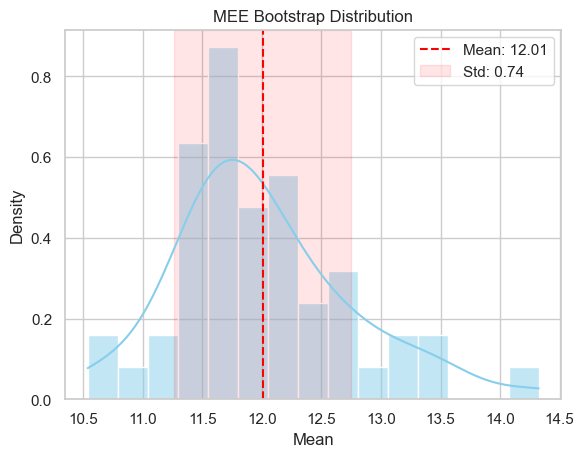

In [19]:
importlib.reload(cr)
cr.plot_bootstrap_distribution([metric.mee for metric in bootstrap_scores])

<h2>Test predictions</h2>
<hr/>

In [20]:
unfitted_model = runner.new_model()
fitted_model = runner.fit(unfitted_model, X_tr, y_tr)
y_pred = runner.predict(fitted_model, X_ts)

print(y_pred)

[[  7.135353   -6.341086 ]
 [-49.053516    6.666115 ]
 [ -4.253919    8.360898 ]
 ...
 [ 25.454237   -4.0175705]
 [-15.972138   30.560715 ]
 [  9.362229   -1.578731 ]]
